In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
#PART 1 - Oluwaloseyitowi Iji & Diane Ingabire

In [ ]:
df = pd.read_csv("data/GaltonFamilies.csv")          # adjust path for Colab if needed
df["father"] = pd.to_numeric(df["father"], errors="coerce")
df["childHeight"] = pd.to_numeric(df["childHeight"], errors="coerce")


In [ ]:
df.head()

,rownames,family,father,mother,midparentHeight,children,childNum,gender,childHeight
0,1,001,78.5,67.0,75.43,4,1,male,73.2
1,2,001,78.5,67.0,75.43,4,2,female,69.2
2,3,001,78.5,67.0,75.43,4,3,female,69.0
3,4,001,78.5,67.0,75.43,4,4,female,69.0
4,5,002,75.5,66.5,73.66,4,1,male,73.5


In [ ]:
fathers = df.drop_duplicates("family")["father"].dropna().to_numpy()
children = df["childHeight"].dropna().to_numpy()

In [ ]:
x = np.concatenate([fathers, children])         # the mixture we feed to EM
true_label = np.array(["father"] * len(fathers) + ["child"] * len(children))  # kept ONLY to check EM afterwards
N = len(x)


In [ ]:
def gaussian(x, mu, var):
    """Height of the bell curve (mean mu, variance var) at point x."""
    return np.exp(-(x - mu) ** 2 / (2 * var)) / np.sqrt(2 * np.pi * var)

In [ ]:
def log_likelihood(x, mu1, mu2, var1, var2, pi1, pi2):
    """Total log-probability of the data under the current mixture.
    This is the single score EM pushes UP every iteration."""
    mixed = pi1 * gaussian(x, mu1, var1) + pi2 * gaussian(x, mu2, var2)
    return np.sum(np.log(mixed))

In [ ]:
global_mean = x.mean()
low = x[x < global_mean]     # everyone below the average -> pile 1
high = x[x >= global_mean]  # everyone above the average -> pile 2

In [ ]:
mu1, mu2 = low.mean(), high.mean()
var1, var2 = low.var(), high.var()
pi1, pi2 = len(low) / N, len(high) / N

In [ ]:
def em(x, mu1, mu2, var1, var2, pi1, pi2, max_iters=500, tol=1e-6, verbose=True):
    history = []
 
    def record(it, ll):
        history.append((it, mu1, mu2, var1, var2, pi1, pi2, ll))
 
    ll = log_likelihood(x, mu1, mu2, var1, var2, pi1, pi2)
    record(0, ll)
    if verbose:
        print(f"{'it':>3}{'mu1':>9}{'mu2':>9}{'var1':>9}{'var2':>9}{'pi1':>7}{'pi2':>7}{'LL':>11}")
        print(f"{0:>3}{mu1:9.3f}{mu2:9.3f}{var1:9.3f}{var2:9.3f}{pi1:7.3f}{pi2:7.3f}{ll:11.2f}")
 
    prev = ll
    for it in range(1, max_iters + 1):
        # ---- E-step: responsibilities (soft assignment) ----
        r1 = pi1 * gaussian(x, mu1, var1)    # unnormalized pull toward comp 1
        r2 = pi2 * gaussian(x, mu2, var2)    # unnormalized pull toward comp 2
        total = r1 + r2
        g1 = r1 / total                      # P(comp1 | height)
        g2 = r2 / total                      # P(comp2 | height)
 
        # ---- M-step: re-estimate each curve using the soft assignments ----
        N1, N2 = g1.sum(), g2.sum()          # soft count
        mu1 = (g1 * x).sum() / N1
        mu2 = (g2 * x).sum() / N2
        var1 = (g1 * (x - mu1) ** 2).sum() / N1
        var2 = (g2 * (x - mu2) ** 2).sum() / N2
        pi1, pi2 = N1 / N, N2 / N
 
        ll = log_likelihood(x, mu1, mu2, var1, var2, pi1, pi2)
        record(it, ll)
        if verbose and it <= 2:              # print the first two updates for the table
            print(f"{it:>3}{mu1:9.3f}{mu2:9.3f}{var1:9.3f}{var2:9.3f}{pi1:7.3f}{pi2:7.3f}{ll:11.2f}")
 
        if abs(ll - prev) < tol:
            break
        prev = ll
 
    params = dict(mu1=mu1, mu2=mu2, var1=var1, var2=var2, pi1=pi1, pi2=pi2)
    return params, history, it


In [ ]:
params, history, n_iters = em(x, mu1, mu2, var1, var2, pi1, pi2)

In [ ]:
if params["mu1"] > params["mu2"]:
    params = dict(mu1=params["mu2"], mu2=params["mu1"], var1=params["var2"],
                  var2=params["var1"], pi1=params["pi2"], pi2=params["pi1"])

In [ ]:
print(f"\nConverged in {n_iters} iterations.")
print(f"  Component 1 (shorter): mu={params['mu1']:.2f}  sigma={np.sqrt(params['var1']):.2f}  pi={params['pi1']:.3f}")
print(f"  Component 2 (taller) : mu={params['mu2']:.2f}  sigma={np.sqrt(params['var2']):.2f}  pi={params['pi2']:.3f}")

In [ ]:
r1 = params["pi1"] * gaussian(x, params["mu1"], params["var1"])
r2 = params["pi2"] * gaussian(x, params["mu2"], params["var2"])
assigned = np.where(r1 >= r2, 1, 2)
print("\nComposition of each recovered component (hard-assigned for inspection):")
for comp in (1, 2):
    sub = true_label[assigned == comp]
    n_father = int((sub == "father").sum())
    n_child = int((sub == "child").sum())
    print(f"  Component {comp}: {n_child} children, {n_father} fathers")

In [ ]:
def classify(height, p=params):
    c1 = p["pi1"] * gaussian(height, p["mu1"], p["var1"])   # shorter component
    c2 = p["pi2"] * gaussian(height, p["mu2"], p["var2"])   # taller component
    total = c1 + c2
    p1, p2 = c1 / total, c2 / total
    print(f"Height {height} in ->  P(shorter/child-leaning) = {p1:.4f}   "
          f"P(taller/father-leaning) = {p2:.4f}")
    return p1, p2

In [ ]:
print("\nExample classifications:")
for h in [62, 64, 67, 70, 73]:
    classify(h)

In [ ]:
grid = np.linspace(x.min(), x.max(), 400)
plt.figure(figsize=(9, 5))
plt.hist(x, bins=30, density=True, alpha=0.35, color="gray", label="pooled heights")
plt.plot(grid, params["pi1"] * gaussian(grid, params["mu1"], params["var1"]),
         linewidth=2, label="Component 1 (shorter)")
plt.plot(grid, params["pi2"] * gaussian(grid, params["mu2"], params["var2"]),
         linewidth=2, label="Component 2 (taller)")
plt.xlabel("Height (inches)"); plt.ylabel("Density")
plt.title("EM-recovered mixture: fathers + children pooled")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

In [ ]:
its = [h[0] for h in history]
lls = [h[7] for h in history]
plt.figure(figsize=(9, 5))
plt.plot(its, lls, marker="o", color="crimson")
plt.xlabel("Iteration"); plt.ylabel("Log-Likelihood")
plt.title("Log-likelihood increases every iteration")
plt.grid(True, alpha=0.3); plt.show()

In [ ]:
#PART 2 - Oluwaloseyitowi Iji


In [ ]:
df = pd.read_csv("data/IMDB Dataset.csv", delimiter=",")
df.head()

In [ ]:
positive_keywords = ["excellent", "wonderful", "brilliant"]
negative_keywords = ["waste", "worst", "boring"]

In [ ]:
total = len(df)
is_pos = df["sentiment"] == "positive"
positives = df[is_pos]
is_neg = df["sentiment"] == "negative"
negatives = df[is_neg]
positives

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
...,...,...
49983,"I loved it, having been a fan of the original ...",positive
49985,Imaginary Heroes is clearly the best film of t...,positive
49989,I got this one a few weeks ago and love it! It...,positive
49992,John Garfield plays a Marine who is blinded by...,positive


In [ ]:
prior = len(positives) / total
prior

0.5

In [ ]:
def bayes(keyword):
    has_kw = df["review"].str.contains(rf"\b{keyword}\b", case=False, regex=True)

    likelihood = (has_kw & is_pos).sum() / prior         # P(keyword | Positive)
    marginal   = has_kw.sum()/len(df)                    # P(keyword)
    posterior  = (likelihood * prior) / marginal         # P(Positive | keyword)

    return prior, likelihood, marginal, posterior

In [ ]:
rows = []
for kw in positive_keywords + negative_keywords:
    prior_, like_, marg_, post_ = bayes(kw)
    rows.append([kw, prior_, like_, marg_, post_])

results = pd.DataFrame(
    rows, columns=["keyword", "prior", "likelihood", "marginal", "posterior"]
)
results.round(4)

,keyword,prior,likelihood,marginal,posterior
0,excellent,0.5,5736.0,0.0710,40371.6216
1,wonderful,0.5,4516.0,0.0556,40611.5108
2,brilliant,0.5,3174.0,0.0418,38002.8736
3,waste,0.5,350.0,0.0507,3453.0387
4,worst,0.5,822.0,0.0887,4634.6414
5,boring,0.5,1182.0,0.0610,9685.3491


In [ ]:
#Part 4 - Esther Mahoro 
import numpy as np
from scipy.differentiate import derivative
import matplotlib.pyplot as plt

In [ ]:
X = np.array([[1, 3],
            [4, 10]])
y = np.array ([5, 6])

#Initial parameters
m = np.array([-1.0, 2.0])
b = np.array([1, 1])

#Learning rate
alpha = 0.001

print("X =\n", X)
print("y =", y)
print("Initial m =", m)
print("Initial b =", b)

X =
 [[ 1  3]
 [ 4 10]]
y = [5 6]
Initial m = [-1.  2.]
Initial b = [1 1]


In [ ]:
def predict(X, m, b):
    y_pred = X @ m + b
    return y_pred

In [ ]:
def compute_mse(y_pred, y):
    n = len(y)
    mse = (1/n) * np.sum((y_pred - y)**2)
    return mse

In [ ]:
# Testing with initial values
y_pred = predict(X, m, b)
mse = compute_mse(y_pred, y)

print("Initial Predictions (y_pred):", y_pred)
print("Actual values (y)           :", y)
print("Error (y_pred - y)          :", y_pred - y)
print("Initial MSE                 :", mse)

Initial Predictions (y_pred): [ 6. 17.]
Actual values (y)           : [5 6]
Error (y_pred - y)          : [ 1. 11.]
Initial MSE                 : 61.0


In [ ]:
from scipy.differentiate import derivative

def mse_vs_b(b_val):
    y_pred = X @ m + b_val
    return (1/len(y)) * np.sum((y_pred - y)**2)

def mse_vs_m1(m1_val):
    y_pred = X @ np.array([m1_val, m[1]]) + b
    return (1/len(y)) * np.sum((y_pred - y)**2)

def mse_vs_m2(m2_val):
    y_pred = X @ np.array([m[0], m2_val]) + b
    return (1/len(y)) * np.sum((y_pred - y)**2)

mse_vs_b_vec  = np.vectorize(mse_vs_b)
mse_vs_m1_vec = np.vectorize(mse_vs_m1)
mse_vs_m2_vec = np.vectorize(mse_vs_m2)

# SciPy computes each gradient 
grad_b  = derivative(mse_vs_b_vec,  float(b[0])).df
grad_m1 = derivative(mse_vs_m1_vec, float(m[0])).df
grad_m2 = derivative(mse_vs_m2_vec, float(m[1])).df

print("Gradients at our starting values:")
print("How steep is the slope for b  :", round(grad_b,  4))
print("How steep is the slope for m1 :", round(grad_m1, 4))
print("How steep is the slope for m2 :", round(grad_m2, 4))

Gradients at our starting values:
How steep is the slope for b  : 12.0
How steep is the slope for m1 : 45.0
How steep is the slope for m2 : 113.0


In [ ]:
m_history = [m.copy()]
b_history  = [b]
mse_history = []

# Compute and store starting MSE
y_pred = X @ m+ b
mse_history.append(compute_mse(y_pred, y))

print("Starting Point")
print("m =", m, "| b =", b, "| MSE =", mse_history[0])
print()

for i in range(1, 5):

    # Make predictions with current m and b
    y_pred = X @ m + b

    # Compute MSE
    mse = compute_mse(y_pred, y)

    # Finding the gradients using SciPy
    grad_b  = derivative(mse_vs_b_vec,  float(b[0])).df
    grad_m1 = derivative(mse_vs_m1_vec, float(m[0])).df
    grad_m2 = derivative(mse_vs_m2_vec, float(m[1])).df


    # Update m and b using gradient descent formula
    m[0] = m[0] - alpha * grad_m1
    m[1] = m[1] - alpha * grad_m2
    b    = b    - alpha * grad_b

    # Compute new MSE after update
    y_pred_new = X @ m + b
    mse_new = compute_mse(y_pred_new, y)

    m_history.append(m.copy())
    b_history.append(b)
    mse_history.append(mse_new)

    print(f" Iteration {i} (Member {i}) ")
    print("Predictions :", y_pred)
    print("Errors      :", y_pred - y)
    print("Gradient m1 :", round(grad_m1, 4))
    print("Gradient m2 :", round(grad_m2, 4))
    print("Gradient b  :", round(grad_b,  4))
    print("Updated m   :", m)
    print("Updated b   :", np.round(b, 4))
    print("New MSE     :", round(mse_new, 4))
    print()

Starting Point
m = [-1.  2.] | b = [1 1] | MSE = 61.0

 Iteration 1 (Member 1) 
Predictions : [ 6. 17.]
Errors      : [ 1. 11.]
Gradient m1 : 45.0
Gradient m2 : 113.0
Gradient b  : 12.0
Updated m   : [-1.045  1.887]
Updated b   : [0.988 0.988]
New MSE     : 47.0143

 Iteration 2 (Member 2) 
Predictions : [ 5.604 15.678]
Errors      : [0.604 9.678]
Gradient m1 : 39.316
Gradient m2 : 98.592
Gradient b  : 10.282
Updated m   : [-1.084316  1.788408]
Updated b   : [0.9777 0.9777]
New MSE     : 36.3673

 Iteration 3 (Member 3) 
Predictions : [ 5.258626 14.524534]
Errors      : [0.258626 8.524534]
Gradient m1 : 34.3568
Gradient m2 : 86.0212
Gradient b  : 8.7832
Updated m   : [-1.11867276  1.70238678]
Updated b   : [0.9689 0.9689]
New MSE     : 28.2619

 Iteration 4 (Member 4) 
Predictions : [ 4.95742242 13.51811161]
Errors      : [-0.04257758  7.51811161]
Gradient m1 : 30.0299
Gradient m2 : 75.0534
Gradient b  : 7.4755
Updated m   : [-1.14870263  1.6273334 ]
Updated b   : [0.9615 0.9615]
New M

In [ ]:
iterations = [0, 1, 2, 3, 4]

# Pull m1 and m2 values from history
m1_history = [m_h[0] for m_h in m_history]
m2_history = [m_h[1] for m_h in m_history]
b0_history = [b_h[0] for b_h in b_history]

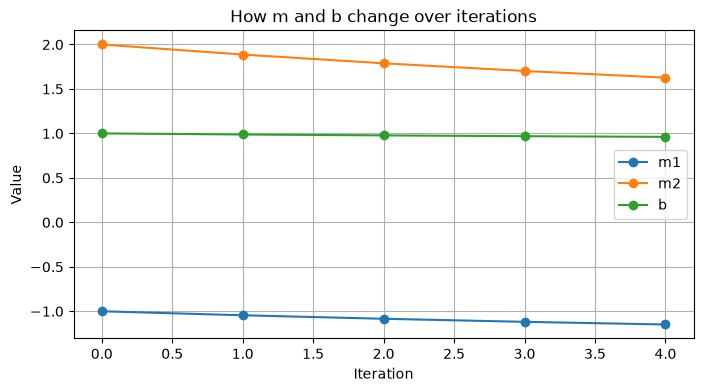

In [ ]:
# Plot 1: How m1, m2 and b change over iterations
plt.figure(figsize=(8, 4))
plt.plot(iterations, m1_history, marker='o', label='m1')
plt.plot(iterations, m2_history, marker='o', label='m2')
plt.plot(iterations, b0_history, marker='o', label='b')
plt.title('How m and b change over iterations')
plt.xlabel('Iteration')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

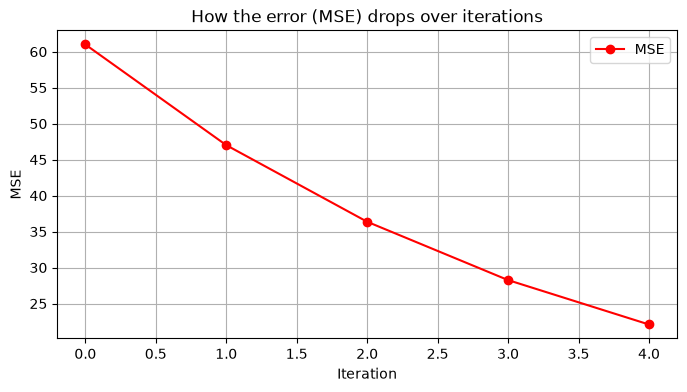

In [ ]:
# Plot 2: How the error changes over iterations
plt.figure(figsize=(8, 4))
plt.plot(iterations, mse_history, marker='o', color='red', label='MSE')
plt.title('How the error (MSE) drops over iterations')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()